# ROI Crop Dataset Preparation
**Input**: side-by-side PNG files — left half = OCT scan, right half = colour segmentation mask  
**Output**: two folders — `crop_oct/` (grayscale ROI crops) and `crop_mask/` (matching colour mask crops)  
**Dataset size**: ~3046 images → Strategy A training (batch_size=1)

---
### What this notebook does
1. Splits each side-by-side image into OCT + mask halves
2. Detects the ROI bounding box from non-black pixels in the mask
3. Adds a configurable margin around the ROI
4. Validates each pair (skips empty/corrupt images)
5. Saves crops and produces a full QC report with visualisation


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
import shutil, json, os
from collections import defaultdict

print('Libraries loaded.')

Libraries loaded.


In [13]:
# ══════════════════════════════════════════════════════════════════════════
# CONFIG  — edit these paths
# ══════════════════════════════════════════════════════════════════════════

BASE = r'D:\Academic\L4S1\ComprehensiveGroupProject\FYP'

# Folder containing your raw side-by-side PNG files
RAW_DIR      = f'{BASE}/data/dataset'

# Output folders (created automatically)
CROP_OCT_DIR  = f'{BASE}/data/New folder/output/crop_oct'
CROP_MASK_DIR = f'{BASE}/data/New folder/output/crop_mask'

# Margin (pixels) added around the ROI bounding box on each side
# Gives the model a little context beyond the tight lesion boundary
MARGIN = 20

# Threshold: pixels with ALL channels below this are treated as background
# Keep at 15 to tolerate JPEG compression artefacts near mask edges
BG_THRESHOLD = 15

# Minimum foreground pixels required to keep a crop (skip near-empty masks)
MIN_FG_PIXELS = 50

# Supported extensions
EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff'}

# Class colour map (RGB) — must match your masks exactly
CLASS_INFO = {
    0: {'name': 'Background',    'color': (0,   0,   0)},
    1: {'name': 'Retinal Layer', 'color': (255, 0,   255)},  # Magenta
    2: {'name': 'PED',           'color': (255, 255, 0)},    # Yellow
    3: {'name': 'SRF',           'color': (255, 0,   0)},    # Red
    4: {'name': 'IRF',           'color': (0,   0,   255)},  # Blue
    5: {'name': 'RPE',           'color': (0,   255, 0)},    # Green
}

print(f'RAW_DIR      : {RAW_DIR}')
print(f'CROP_OCT_DIR : {CROP_OCT_DIR}')
print(f'CROP_MASK_DIR: {CROP_MASK_DIR}')
print(f'Margin       : {MARGIN}px')

RAW_DIR      : D:\Academic\L4S1\ComprehensiveGroupProject\FYP/data/dataset
CROP_OCT_DIR : D:\Academic\L4S1\ComprehensiveGroupProject\FYP/data/New folder/output/crop_oct
CROP_MASK_DIR: D:\Academic\L4S1\ComprehensiveGroupProject\FYP/data/New folder/output/crop_mask
Margin       : 20px


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════

def split_side_by_side(img_bgr):
    """
    Split a side-by-side image into (oct_bgr, mask_bgr).
    Left half  → OCT scan
    Right half → colour segmentation mask
    """
    H, W = img_bgr.shape[:2]
    mid  = W // 2
    oct_bgr  = img_bgr[:, :mid, :]
    mask_bgr = img_bgr[:, mid:, :]
    return oct_bgr, mask_bgr


def get_roi_bbox(mask_bgr, bg_threshold=BG_THRESHOLD):
    """
    Find the tight bounding box of all non-background pixels in mask_bgr.
    Returns (rmin, rmax, cmin, cmax) or None if no foreground found.
    """
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    fg = (mask_rgb > bg_threshold).any(axis=2)   # True where any channel > threshold

    rows = np.any(fg, axis=1)
    cols = np.any(fg, axis=0)

    if not rows.any():
        return None   # completely empty mask

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return int(rmin), int(rmax), int(cmin), int(cmax)


def apply_margin(rmin, rmax, cmin, cmax, H, W, margin=MARGIN):
    """
    Expand bbox by margin on all sides, clipped to image bounds.
    """
    rmin = max(0, rmin - margin)
    rmax = min(H - 1, rmax + margin)
    cmin = max(0, cmin - margin)
    cmax = min(W - 1, cmax + margin)
    return rmin, rmax, cmin, cmax


def count_fg_pixels(mask_bgr, bg_threshold=BG_THRESHOLD):
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    return int((mask_rgb > bg_threshold).any(axis=2).sum())


def rgb_mask_to_class(mask_bgr):
    """Nearest-colour snap — tolerates JPEG artefacts."""
    mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    pixels   = mask_rgb.reshape(-1, 3).astype(np.float32)
    best_dist = np.full(len(pixels), np.inf)
    best_cls  = np.zeros(len(pixels), dtype=np.uint8)
    for cls_id, info in CLASS_INFO.items():
        ref  = np.array(info['color'], dtype=np.float32)
        dist = np.linalg.norm(pixels - ref, axis=1)
        better = dist < best_dist
        best_dist[better] = dist[better]
        best_cls[better]  = cls_id
    return best_cls.reshape(mask_rgb.shape[:2])


print('Helpers ready.')

Helpers ready.


Found 3049 files in D:\Academic\L4S1\ComprehensiveGroupProject\FYP/data/dataset

Sample file  : 100_100_1.png
Full image   : 1140w x 380h
Half width   : 570
ROI bbox     : rows 121–222, cols 160–511
ROI size     : 101h x 351w
FG pixels    : 10501


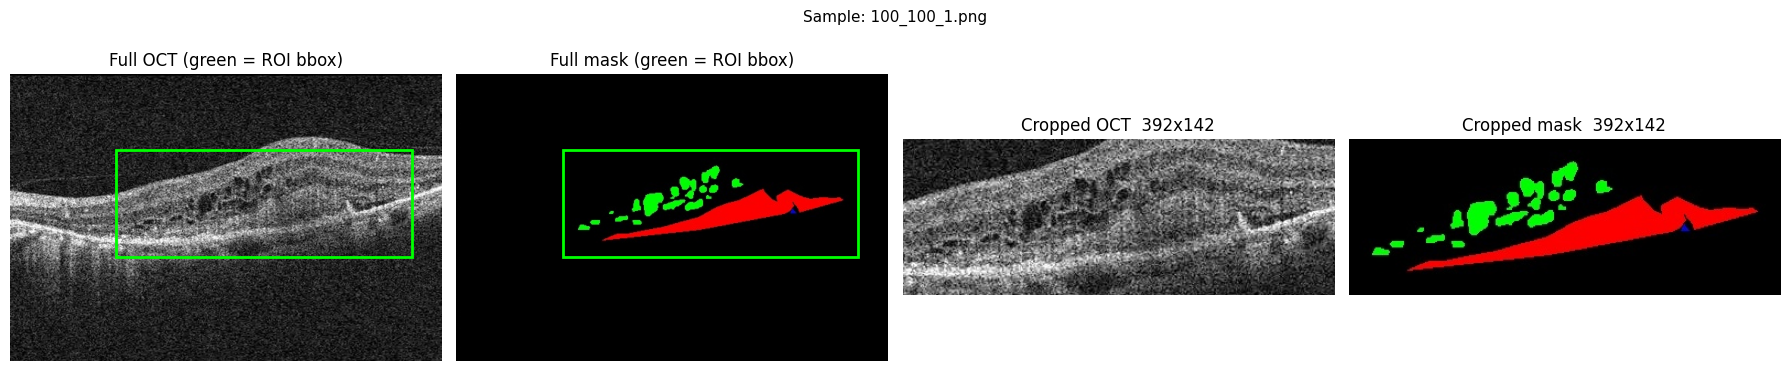


If the crops look correct, run the next cell to process all images.


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 0 — Inspect one sample image to verify split and colours
# ══════════════════════════════════════════════════════════════════════════

raw_dir   = Path(RAW_DIR)
all_files = sorted([f for f in raw_dir.iterdir()
                    if f.suffix.lower() in EXTENSIONS])
print(f'Found {len(all_files)} files in {RAW_DIR}')

if len(all_files) == 0:
    raise FileNotFoundError(f'No images found in {RAW_DIR}. Check the path.')

# Show the first file as a sanity check
sample_path = all_files[0]
sample_bgr  = cv2.imread(str(sample_path))
H, W        = sample_bgr.shape[:2]
print(f'\nSample file  : {sample_path.name}')
print(f'Full image   : {W}w x {H}h')
print(f'Half width   : {W//2}')

oct_bgr, mask_bgr = split_side_by_side(sample_bgr)
bbox = get_roi_bbox(mask_bgr)
print(f'ROI bbox     : rows {bbox[0]}–{bbox[1]}, cols {bbox[2]}–{bbox[3]}')
print(f'ROI size     : {bbox[1]-bbox[0]}h x {bbox[3]-bbox[2]}w')
print(f'FG pixels    : {count_fg_pixels(mask_bgr)}')

# ── Visual check ───────────────────────────────────────────────────────────
rmin, rmax, cmin, cmax = apply_margin(*bbox, H, W//2)
crop_oct  = oct_bgr[rmin:rmax+1, cmin:cmax+1]
crop_mask = mask_bgr[rmin:rmax+1, cmin:cmax+1]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f'Sample: {sample_path.name}', fontsize=11)

oct_rgb = cv2.cvtColor(oct_bgr, cv2.COLOR_BGR2RGB)
axes[0].imshow(oct_rgb, cmap='gray')
axes[0].add_patch(plt.Rectangle((cmin, rmin), cmax-cmin, rmax-rmin,
                                 edgecolor='lime', facecolor='none', lw=2))
axes[0].set_title('Full OCT (green = ROI bbox)')

mask_rgb = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
axes[1].imshow(mask_rgb)
axes[1].add_patch(plt.Rectangle((cmin, rmin), cmax-cmin, rmax-rmin,
                                 edgecolor='lime', facecolor='none', lw=2))
axes[1].set_title('Full mask (green = ROI bbox)')

axes[2].imshow(cv2.cvtColor(crop_oct, cv2.COLOR_BGR2RGB), cmap='gray')
axes[2].set_title(f'Cropped OCT  {crop_oct.shape[1]}x{crop_oct.shape[0]}')

axes[3].imshow(cv2.cvtColor(crop_mask, cv2.COLOR_BGR2RGB))
axes[3].set_title(f'Cropped mask  {crop_mask.shape[1]}x{crop_mask.shape[0]}')

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print('\nIf the crops look correct, run the next cell to process all images.')

Scanning all images for ROI size distribution...
(This takes ~1 min for 3000 images — reads headers only)


Scanning: 100%|████████████████████████| 3049/3049 [02:08<00:00, 23.79it/s]



Total images      : 3049
Valid pairs       : 3049
Empty masks       : 0

Crop HEIGHT  — min:48  max:281  mean:128  std:37
Crop WIDTH   — min:43  max:570  mean:525  std:88

Height range: 182% of mean  |  Width range: 100% of mean
→ Sizes vary significantly. Strategy A (batch=1) or B (dynamic pad) is better.


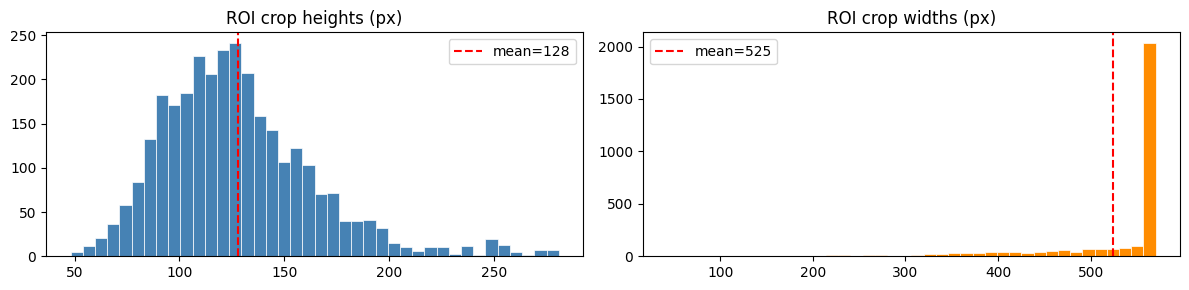

In [16]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 1 — Analyse size distribution before committing to a strategy
# ══════════════════════════════════════════════════════════════════════════

print('Scanning all images for ROI size distribution...')
print('(This takes ~1 min for 3000 images — reads headers only)')

heights, widths = [], []
empty_count = 0

for fpath in tqdm(all_files, desc='Scanning'):
    img = cv2.imread(str(fpath))
    if img is None:
        continue
    _, mask_half = split_side_by_side(img)
    bbox = get_roi_bbox(mask_half)
    if bbox is None:
        empty_count += 1
        continue
    H_img, W_img = mask_half.shape[:2]
    rmin, rmax, cmin, cmax = apply_margin(*bbox, H_img, W_img)
    heights.append(rmax - rmin + 1)
    widths.append(cmax - cmin + 1)

heights = np.array(heights)
widths  = np.array(widths)

print(f'\nTotal images      : {len(all_files)}')
print(f'Valid pairs       : {len(heights)}')
print(f'Empty masks       : {empty_count}')
print(f'\nCrop HEIGHT  — min:{heights.min()}  max:{heights.max()}'
      f'  mean:{heights.mean():.0f}  std:{heights.std():.0f}')
print(f'Crop WIDTH   — min:{widths.min()}  max:{widths.max()}'
      f'  mean:{widths.mean():.0f}  std:{widths.std():.0f}')

h_range_pct = (heights.max() - heights.min()) / heights.mean() * 100
w_range_pct = (widths.max()  - widths.min())  / widths.mean()  * 100
print(f'\nHeight range: {h_range_pct:.0f}% of mean  |  Width range: {w_range_pct:.0f}% of mean')
if max(h_range_pct, w_range_pct) < 60:
    print('→ Sizes are relatively similar. Strategy C (resize to fixed) is also viable.')
else:
    print('→ Sizes vary significantly. Strategy A (batch=1) or B (dynamic pad) is better.')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(heights, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(heights.mean(), color='red', linestyle='--', label=f'mean={heights.mean():.0f}')
axes[0].set_title('ROI crop heights (px)'); axes[0].legend()
axes[1].hist(widths,  bins=40, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].axvline(widths.mean(),  color='red', linestyle='--', label=f'mean={widths.mean():.0f}')
axes[1].set_title('ROI crop widths (px)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [17]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 2 — Process all images and save crops
# ══════════════════════════════════════════════════════════════════════════

# Create output directories (clean them first if they exist)
for d in [CROP_OCT_DIR, CROP_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Saving crops to:')
print(f'  OCT  : {CROP_OCT_DIR}')
print(f'  Mask : {CROP_MASK_DIR}')
print()

stats = {
    'saved'           : 0,
    'skipped_empty'   : 0,
    'skipped_few_fg'  : 0,
    'skipped_unreadable': 0,
}
skipped_log   = []
saved_sizes   = []   # (h, w) of each saved crop
class_pixel_counts = defaultdict(int)  # for class weight computation later

for fpath in tqdm(all_files, desc='Processing'):

    # ── Load ────────────────────────────────────────────────────────────
    img_bgr = cv2.imread(str(fpath))
    if img_bgr is None:
        stats['skipped_unreadable'] += 1
        skipped_log.append((fpath.name, 'unreadable'))
        continue

    oct_bgr, mask_bgr = split_side_by_side(img_bgr)
    H_half, W_half    = mask_bgr.shape[:2]

    # ── Detect ROI bbox ─────────────────────────────────────────────────
    bbox = get_roi_bbox(mask_bgr)
    if bbox is None:
        stats['skipped_empty'] += 1
        skipped_log.append((fpath.name, 'empty mask'))
        continue

    # ── Validate foreground pixel count ─────────────────────────────────
    fg_px = count_fg_pixels(mask_bgr)
    if fg_px < MIN_FG_PIXELS:
        stats['skipped_few_fg'] += 1
        skipped_log.append((fpath.name, f'too few fg pixels ({fg_px})'))
        continue

    # ── Apply margin and crop ────────────────────────────────────────────
    rmin, rmax, cmin, cmax = apply_margin(*bbox, H_half, W_half)
    crop_oct  = oct_bgr [rmin:rmax+1, cmin:cmax+1]
    crop_mask = mask_bgr[rmin:rmax+1, cmin:cmax+1]

    # ── Accumulate class pixel counts (for class weight computation) ─────
    cls_map = rgb_mask_to_class(crop_mask)
    for c in range(len(CLASS_INFO)):
        class_pixel_counts[c] += int((cls_map == c).sum())

    # ── Save ────────────────────────────────────────────────────────────
    # Use .png to avoid any lossy compression on the mask
    out_name = fpath.stem + '.png'
    cv2.imwrite(str(Path(CROP_OCT_DIR)  / out_name), crop_oct)
    cv2.imwrite(str(Path(CROP_MASK_DIR) / out_name), crop_mask)

    stats['saved'] += 1
    saved_sizes.append((crop_oct.shape[0], crop_oct.shape[1]))

# ── Summary ──────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('  DATASET PREPARATION COMPLETE')
print('='*60)
print(f'  Saved            : {stats["saved"]} pairs')
print(f'  Skipped (empty)  : {stats["skipped_empty"]}')
print(f'  Skipped (few fg) : {stats["skipped_few_fg"]}')
print(f'  Skipped (corrupt): {stats["skipped_unreadable"]}')
print('='*60)

if skipped_log:
    print(f'\nFirst 10 skipped:')
    for name, reason in skipped_log[:10]:
        print(f'  {name}  —  {reason}')

Saving crops to:
  OCT  : D:\Academic\L4S1\ComprehensiveGroupProject\FYP/data/New folder/output/crop_oct
  Mask : D:\Academic\L4S1\ComprehensiveGroupProject\FYP/data/New folder/output/crop_mask



Processing: 100%|██████████████████████| 3049/3049 [01:49<00:00, 27.76it/s]


  DATASET PREPARATION COMPLETE
  Saved            : 3049 pairs
  Skipped (empty)  : 0
  Skipped (few fg) : 0
  Skipped (corrupt): 0


In [18]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 3 — Compute and save class weights for training
# (Run this after processing — reuses the pixel counts collected above)
# ══════════════════════════════════════════════════════════════════════════

total_pixels = sum(class_pixel_counts.values())
num_classes  = len(CLASS_INFO)

freq    = np.array([class_pixel_counts[c] / total_pixels
                    for c in range(num_classes)], dtype=np.float64)
weights = np.clip(1.0 / (freq + 1e-6), 0, 10.0)
weights /= weights.mean()

print('Class pixel frequencies and training weights:')
print(f'  {"Class":<18} {"Pixels":>12}  {"Freq":>8}  {"Weight":>8}')
print('  ' + '-'*52)
for c in range(num_classes):
    bar = '█' * int(weights[c] * 8)
    print(f'  {CLASS_INFO[c]["name"]:<18} {class_pixel_counts[c]:>12,}'
          f'  {freq[c]:>8.4f}  {weights[c]:>8.3f}  {bar}')

# Save weights to JSON so training notebook can load them directly
weights_path = Path(BASE) / 'data' / 'class_weights_roi.json'
weights_path.parent.mkdir(parents=True, exist_ok=True)
with open(weights_path, 'w') as f:
    json.dump({
        'weights': weights.tolist(),
        'frequencies': freq.tolist(),
        'pixel_counts': {str(k): int(v) for k, v in class_pixel_counts.items()},
        'class_names': [CLASS_INFO[c]['name'] for c in range(num_classes)],
    }, f, indent=2)
print(f'\nClass weights saved → {weights_path}')
print('Load in training notebook with:')
print("  import json, torch")
print(f"  w = json.load(open(r'{weights_path}'))['weights']")
print("  class_weights = torch.tensor(w, dtype=torch.float32)")

Class pixel frequencies and training weights:
  Class                    Pixels      Freq    Weight
  ----------------------------------------------------
  Background          182,408,378    0.8866     0.132  █
  Retinal Layer         3,622,350    0.0176     1.174  █████████
  PED                   6,133,966    0.0298     1.174  █████████
  SRF                   5,730,522    0.0279     1.174  █████████
  IRF                   6,643,660    0.0323     1.174  █████████
  RPE                   1,194,175    0.0058     1.174  █████████

Class weights saved → D:\Academic\L4S1\ComprehensiveGroupProject\FYP\data\class_weights_roi.json
Load in training notebook with:
  import json, torch
  w = json.load(open(r'D:\Academic\L4S1\ComprehensiveGroupProject\FYP\data\class_weights_roi.json'))['weights']
  class_weights = torch.tensor(w, dtype=torch.float32)


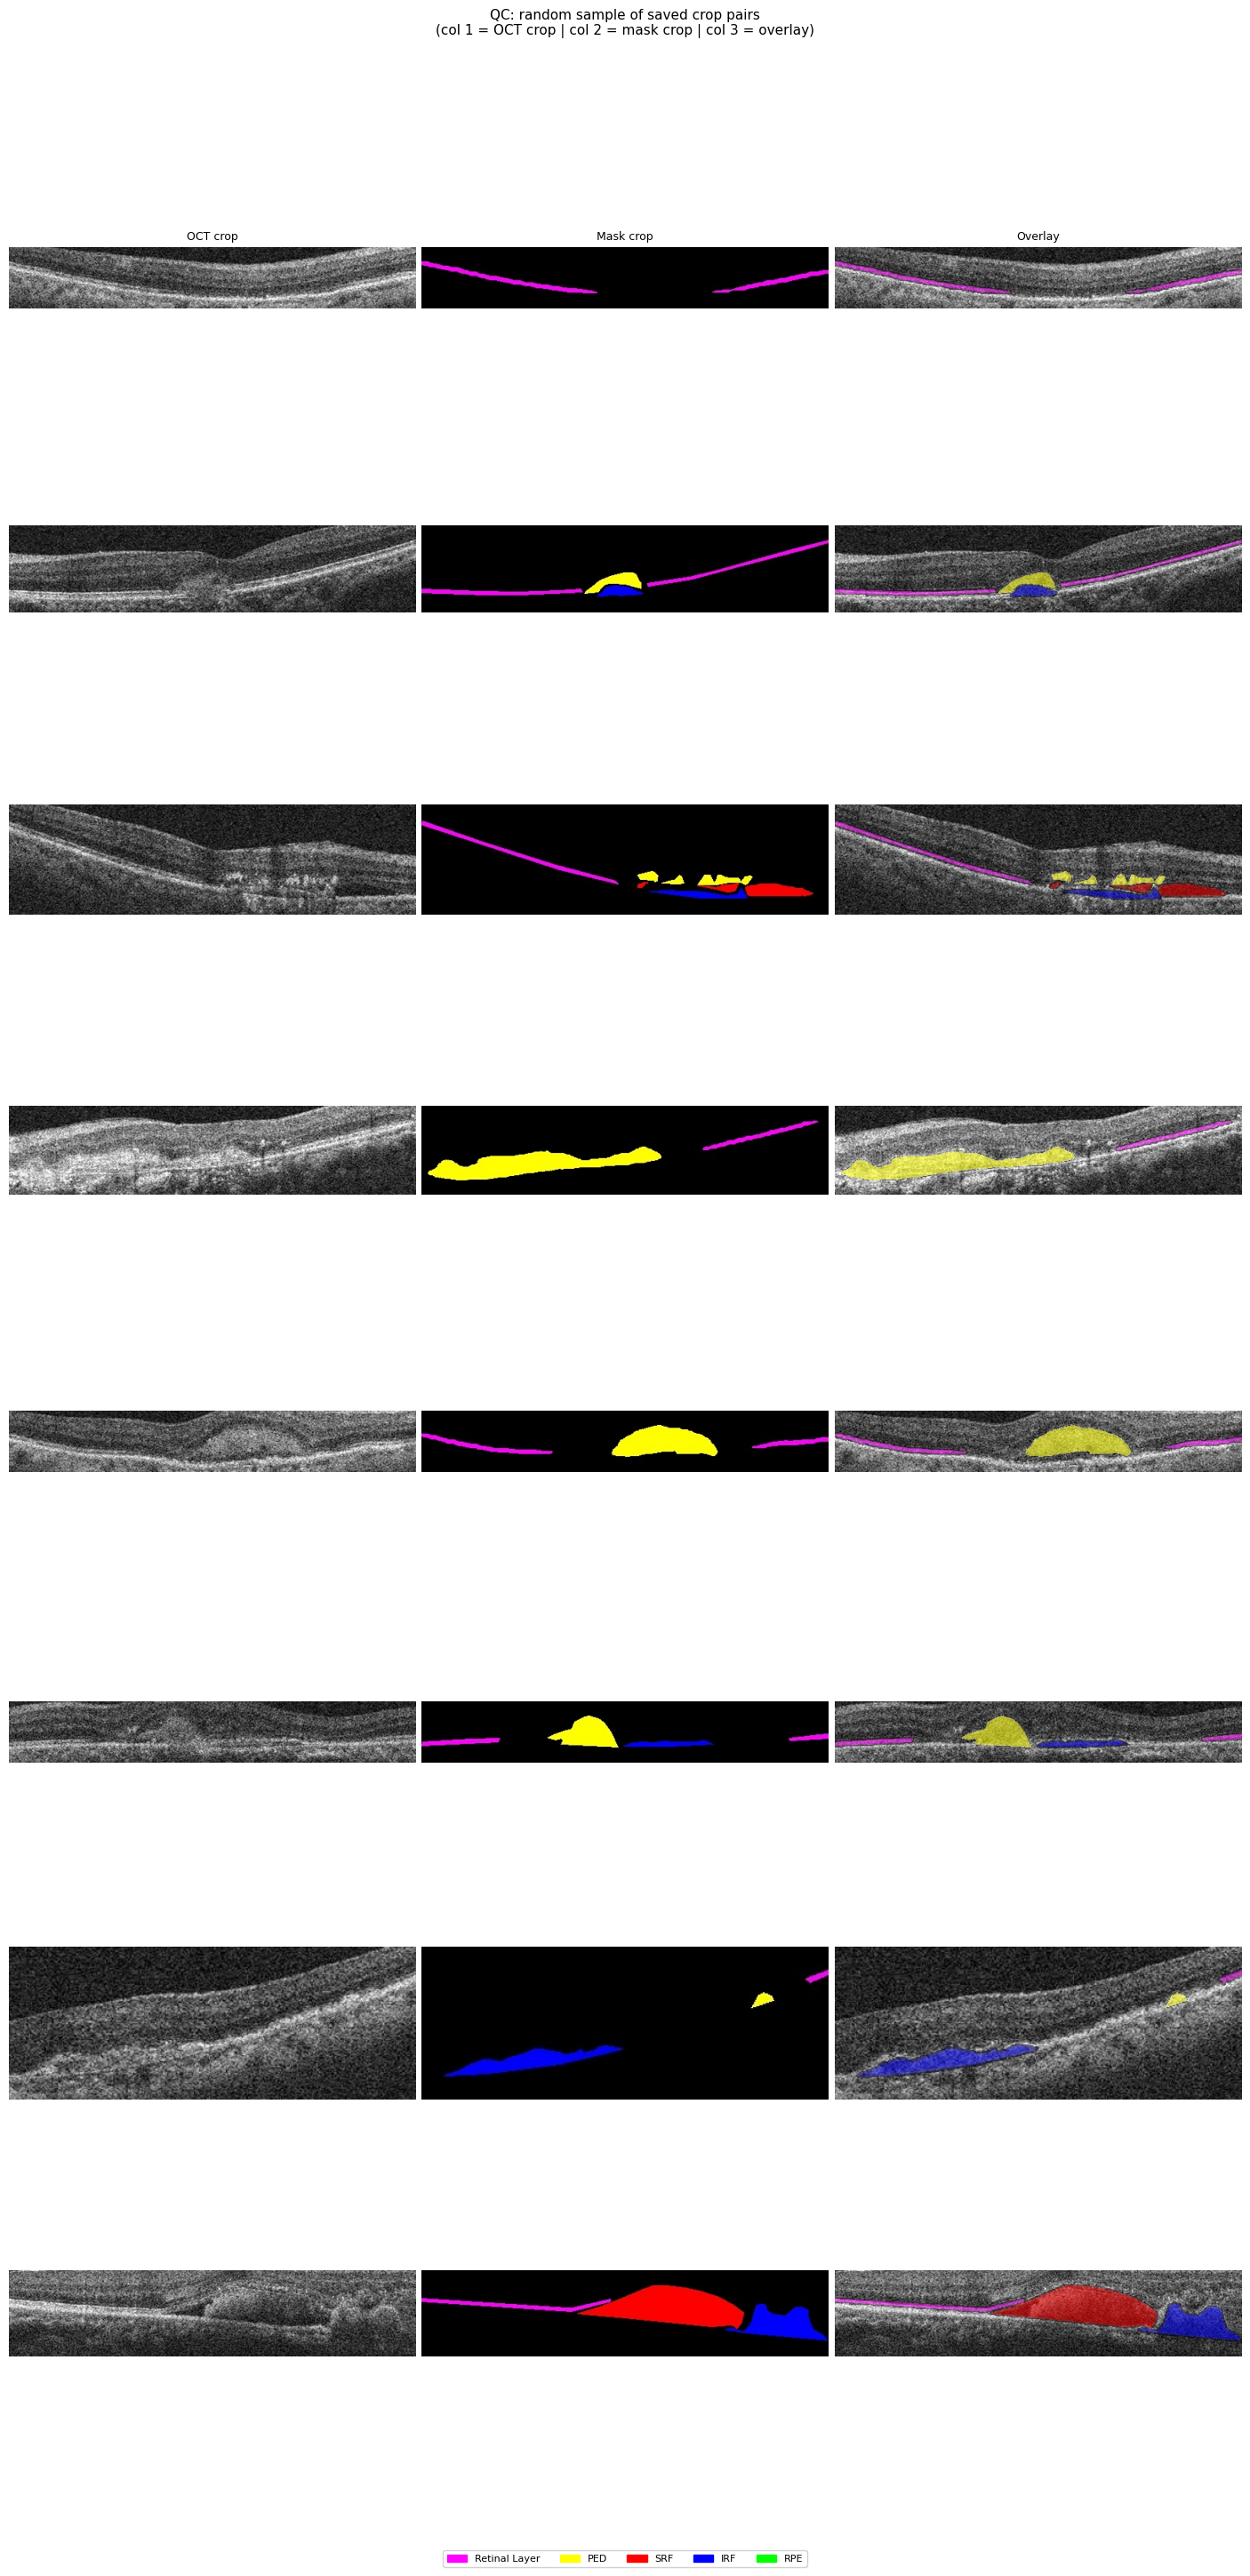


Total saved pairs: 3049


In [19]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 4 — QC visualisation: random sample grid
# Shows 8 random crop pairs so you can visually verify quality
# ══════════════════════════════════════════════════════════════════════════

import random

crop_oct_dir  = Path(CROP_OCT_DIR)
crop_mask_dir = Path(CROP_MASK_DIR)

saved_files = sorted(list(crop_oct_dir.glob('*.png')))
sample_files = random.sample(saved_files, min(8, len(saved_files)))

fig, axes = plt.subplots(len(sample_files), 3,
                          figsize=(14, 3.5 * len(sample_files)))
fig.suptitle('QC: random sample of saved crop pairs\n'
             '(col 1 = OCT crop | col 2 = mask crop | col 3 = overlay)',
             fontsize=11, y=1.01)

# Class colour legend patches
legend_handles = [
    mpatches.Patch(color=np.array(info['color'])/255, label=info['name'])
    for _, info in CLASS_INFO.items() if info['name'] != 'Background'
]

for row, fpath in enumerate(sample_files):
    oct_bgr  = cv2.imread(str(fpath))
    mask_bgr = cv2.imread(str(crop_mask_dir / fpath.name))

    oct_gray  = cv2.cvtColor(oct_bgr, cv2.COLOR_BGR2GRAY)
    mask_rgb  = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)

    # Overlay: grayscale OCT + semi-transparent mask
    oct_rgb3  = cv2.cvtColor(oct_gray, cv2.COLOR_GRAY2RGB)
    # Only overlay where mask is non-black
    fg_region = (mask_rgb > BG_THRESHOLD).any(axis=2)
    overlay   = oct_rgb3.copy().astype(float)
    overlay[fg_region] = (
        0.45 * oct_rgb3[fg_region] + 0.55 * mask_rgb[fg_region]
    )
    overlay = overlay.astype(np.uint8)

    h, w  = oct_bgr.shape[:2]
    title = f'{fpath.name}  [{w}×{h}]'

    axes[row, 0].imshow(oct_gray, cmap='gray')
    axes[row, 0].set_ylabel(title, fontsize=7.5, rotation=90, labelpad=4)
    axes[row, 1].imshow(mask_rgb)
    axes[row, 2].imshow(overlay)

    for ax in axes[row]: ax.axis('off')

axes[0, 0].set_title('OCT crop',       fontsize=9)
axes[0, 1].set_title('Mask crop',      fontsize=9)
axes[0, 2].set_title('Overlay',        fontsize=9)

fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(pad=0.5)
plt.show()
print(f'\nTotal saved pairs: {len(saved_files)}')

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 5 — Train / Validation split
# Produces train.txt and val.txt listing filenames for training notebook
# ══════════════════════════════════════════════════════════════════════════

VAL_FRACTION = 0.15   # 15% validation
SEED         = 42

random.seed(SEED)
all_stems = sorted([f.stem for f in crop_oct_dir.glob('*.png')])
random.shuffle(all_stems)

n_val   = max(1, int(len(all_stems) * VAL_FRACTION))
n_train = len(all_stems) - n_val

train_stems = all_stems[:n_train]
val_stems   = all_stems[n_train:]

split_dir = Path(BASE) / 'data'
with open(split_dir / 'train.txt', 'w') as f:
    f.write('\n'.join(train_stems))
with open(split_dir / 'val.txt', 'w') as f:
    f.write('\n'.join(val_stems))

print(f'Split complete  (seed={SEED})')
print(f'  Train : {n_train} images  → {split_dir}/train.txt')
print(f'  Val   : {n_val} images   → {split_dir}/val.txt')

# Final summary
saved_h = np.array([s[0] for s in saved_sizes])
saved_w = np.array([s[1] for s in saved_sizes])
print(f'\nFinal crop size stats:')
print(f'  H  min={saved_h.min()}  max={saved_h.max()}  mean={saved_h.mean():.0f}')
print(f'  W  min={saved_w.min()}  max={saved_w.max()}  mean={saved_w.mean():.0f}')
print('\nDataset preparation complete. Ready for training.')

Split complete  (seed=42)
  Train : 2592 images  → D:\Academic\L4S1\ComprehensiveGroupProject\FYP\data/train.txt
  Val   : 457 images   → D:\Academic\L4S1\ComprehensiveGroupProject\FYP\data/val.txt

Final crop size stats:
  H  min=48  max=281  mean=128
  W  min=43  max=570  mean=525

Dataset preparation complete. Ready for training.
